In [ ]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
try:
    ZIP_PATH = 'potato_leaf.zip'
    EXTRACT_DIR = 'extracted_dataset'

    def extract_zip(zip_path, extract_dir):
        if not os.path.exists(extract_dir):
            os.makedirs(extract_dir)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        extracted_path = os.path.join(extract_dir, 'Potato Leaf (Healthy and Late Blight)')
        if not os.path.exists(extracted_path):
            raise FileNotFoundError("Expected dataset folder not found.")
        return extracted_path

    BASE_DIR = extract_zip(ZIP_PATH, EXTRACT_DIR)
    HEALTHY_DIR = os.path.join(BASE_DIR, 'Healthy')
    LATE_BLIGHT_DIR = os.path.join(BASE_DIR, 'Late Blight')
    AUGMENTED_LATE_BLIGHT_DIR = os.path.join(BASE_DIR, 'Augmented_Late_Blight')

    # Create augmented directory
    os.makedirs(AUGMENTED_LATE_BLIGHT_DIR, exist_ok=True)

    print(f"Dataset extracted to {BASE_DIR}")
    print(f"Healthy directory: {HEALTHY_DIR}")
    print(f"Late Blight directory: {LATE_BLIGHT_DIR}")
    print(f"Augmented Late Blight directory: {AUGMENTED_LATE_BLIGHT_DIR}")
except Exception as e:
    print(f"Failed to extract or set up dataset: {e}")
    raise

Dataset extracted to extracted_dataset/Potato Leaf (Healthy and Late Blight)
Healthy directory: extracted_dataset/Potato Leaf (Healthy and Late Blight)/Healthy
Late Blight directory: extracted_dataset/Potato Leaf (Healthy and Late Blight)/Late Blight
Augmented Late Blight directory: extracted_dataset/Potato Leaf (Healthy and Late Blight)/Augmented_Late_Blight


In [ ]:
try:
    healthy_count = len(os.listdir(HEALTHY_DIR))
    global late_blight_count
    late_blight_count = len(os.listdir(LATE_BLIGHT_DIR))
    if healthy_count == 0 or late_blight_count == 0:
        raise ValueError("One or both directories are empty.")
    print(f"Healthy images: {healthy_count}")
    print(f"Late Blight images: {late_blight_count}")
except Exception as e:
    print(f"Error counting images: {e}")
    raise

Healthy images: 363
Late Blight images: 67


296 images generated and saved to extracted_dataset/Potato Leaf (Healthy and Late Blight)/Augmented_Late_Blight


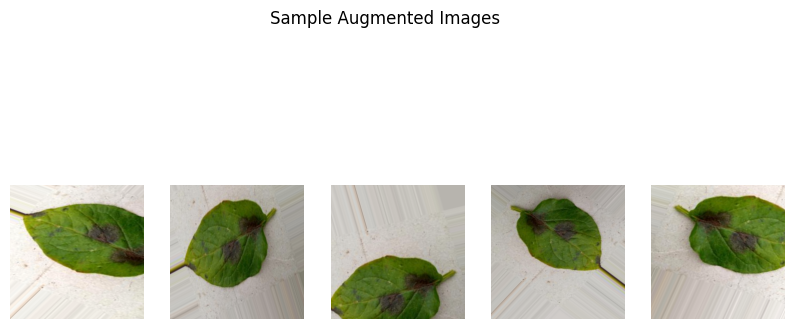

In [ ]:
def augment_images_with_preview(source_dir, target_count, save_dir, preview_count=5):
    datagen = ImageDataGenerator(
        rotation_range=45,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=[0.7, 1.3],
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest',
        channel_shift_range=0.2
    )

    current_count = len(os.listdir(source_dir))
    images_to_generate = target_count - current_count
    generated_count = 0
    preview_images = []

    if images_to_generate <= 0:
        print("No augmentation needed.")
        return

    for img_name in os.listdir(source_dir):
        img_path = os.path.join(source_dir, img_name)
        try:
            img = load_img(img_path)
            img_array = img_to_array(img)
            img_array = img_array.reshape((1,) + img_array.shape)

            i = 0
            for batch in datagen.flow(img_array, batch_size=1, save_to_dir=save_dir,
                                      save_prefix='aug', save_format='jpg'):
                if generated_count < preview_count:
                    preview_images.append(batch[0].astype('uint8'))
                generated_count += 1
                i += 1
                if generated_count >= images_to_generate or i >= 10:
                    break

        except Exception as e:
            print(f"Error processing {img_name}: {e}")

        if generated_count >= images_to_generate:
            break

    print(f"{generated_count} images generated and saved to {save_dir}")

    # Plot sample augmented images
    if preview_images:
        plt.figure(figsize=(10, 5))
        for i, img in enumerate(preview_images):
            plt.subplot(1, preview_count, i+1)
            plt.imshow(img.astype("uint8"))
            plt.axis('off')
        plt.suptitle("Sample Augmented Images")
        plt.show()

# Example usage:
augment_images_with_preview(LATE_BLIGHT_DIR, healthy_count, AUGMENTED_LATE_BLIGHT_DIR)


In [ ]:
import shutil

# Copy images to combined directory
for file in os.listdir(HEALTHY_DIR):
    shutil.copy(os.path.join(HEALTHY_DIR, file), os.path.join(DATASET_DIR, 'Healthy'))

for file in os.listdir(LATE_BLIGHT_DIR):
    shutil.copy(os.path.join(LATE_BLIGHT_DIR, file), os.path.join(DATASET_DIR, 'Late Blight'))
for file in os.listdir(AUGMENTED_LATE_BLIGHT_DIR):
    shutil.copy(os.path.join(AUGMENTED_LATE_BLIGHT_DIR, file), os.path.join(DATASET_DIR, 'Late Blight'))

# Create Data Generators
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 579 images belonging to 2 classes.
Found 144 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('leaf_model.keras', save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4589 - loss: 1.8922 - val_accuracy: 0.5208 - val_loss: 0.6409
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7454 - loss: 0.5676 - val_accuracy: 1.0000 - val_loss: 0.1155
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8903 - loss: 0.2509 - val_accuracy: 1.0000 - val_loss: 0.0402
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9059 - loss: 0.2209 - val_accuracy: 1.0000 - val_loss: 0.0181
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9492 - loss: 0.1276 - val_accuracy: 1.0000 - val_loss: 0.0167
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9767 - loss: 0.0663 - val_accuracy: 0.9375 - val_loss: 0.1428
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9432 - loss: 0.1482 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9852 - loss: 0.0487 - val_accuracy: 1.0000 - val_loss:

Saving potato_unhealthy1.jpeg to potato_unhealthy1 (1).jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


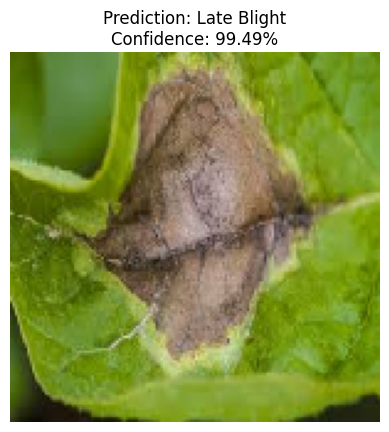

Z-score: 0.9899
P-value: 0.1611


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from scipy.stats import norm
import cv2
from google.colab import files

uploaded = files.upload()
model = load_model("leaf_model.keras")

for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    label = "Late Blight" if prediction >= 0.5 else "Healthy"
    confidence = prediction if label == "Late Blight" else 1 - prediction

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2%}")
    plt.show()

    # Z-test & P-value for bi  nary classification
    z = (confidence - 0.5) / (np.sqrt(0.5 * (1 - 0.5) / 1))  # binomial std deviation
    p_value = 1 - norm.cdf(abs(z))

    print(f"Z-score: {z:.4f}")
    print(f"P-value: {p_value:.4f}")
